In [ ]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
from tensorflow.keras import layers
from tensorflow.keras import datasets
from tensorflow.keras import Sequential

In [86]:
from keras.datasets import cifar10

In [87]:
df=cifar10.load_data()

In [88]:
df

((array([[[[ 59,  62,  63],
           [ 43,  46,  45],
           [ 50,  48,  43],
           ...,
           [158, 132, 108],
           [152, 125, 102],
           [148, 124, 103]],
  
          [[ 16,  20,  20],
           [  0,   0,   0],
           [ 18,   8,   0],
           ...,
           [123,  88,  55],
           [119,  83,  50],
           [122,  87,  57]],
  
          [[ 25,  24,  21],
           [ 16,   7,   0],
           [ 49,  27,   8],
           ...,
           [118,  84,  50],
           [120,  84,  50],
           [109,  73,  42]],
  
          ...,
  
          [[208, 170,  96],
           [201, 153,  34],
           [198, 161,  26],
           ...,
           [160, 133,  70],
           [ 56,  31,   7],
           [ 53,  34,  20]],
  
          [[180, 139,  96],
           [173, 123,  42],
           [186, 144,  30],
           ...,
           [184, 148,  94],
           [ 97,  62,  34],
           [ 83,  53,  34]],
  
          [[177, 144, 116],
           [16

In [89]:
(x_train,y_train),(x_test,y_test)=df

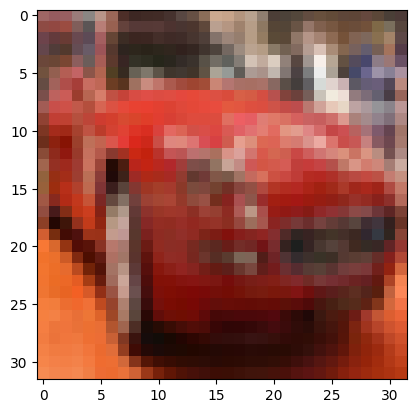

In [90]:
import matplotlib.pyplot as plt
plt.imshow(x_train[5])

In [91]:
y_train[5]

array([1], dtype=uint8)

In [92]:
classess=["plane","automobile",'bird',"cat","deer","dog","frog", "horse","ship","truck"]

In [93]:
classess[1]

'automobile'

In [94]:
x_train.shape

(50000, 32, 32, 3)

In [95]:
model=keras.Sequential([
    layers.Conv2D(32,(3,3),activation="relu",input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(50,activation="relu"),
    keras.layers.Dense(10,activation="softmax")
])

c:\Users\ACER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [96]:
model.compile(metrics=["accuracy"],optimizer="Adam",loss="sparse_categorical_crossentropy")

In [97]:
model.fit(x_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3138 - loss: 2.0181
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4737 - loss: 1.4373
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5335 - loss: 1.2959
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5722 - loss: 1.1997
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6025 - loss: 1.1226
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6241 - loss: 1.0654
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6457 - loss: 1.0149
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6556 - loss: 0.9778
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6718 - loss: 0.9460
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6778 - loss: 0.9181


In [98]:
x_test.shape

(10000, 32, 32, 3)

In [99]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [101]:
y_pred[786]

array([1.40459320e-04, 1.40264365e-05, 2.02306104e-03, 5.02220809e-01,
       2.21141055e-03, 2.07392216e-01, 2.67056286e-01, 1.02402195e-02,
       6.31466391e-04, 8.07005633e-03], dtype=float32)

In [102]:
y_pred[786].argmax()

np.int64(3)

In [103]:
classess[3]

'cat'

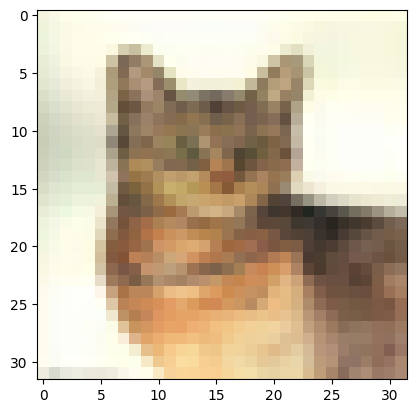

In [105]:
plt.imshow(x_test[786])

In [106]:
x_train.shape

(50000, 32, 32, 3)

In [108]:
x_test.shape

(10000, 32, 32, 3)

In [109]:
model.save("Test.h5")